In [1277]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1278]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
base_path = Path("/content/drive/MyDrive/01_przetwarzanie_wizualizacja_danych") # change to path folder with data

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

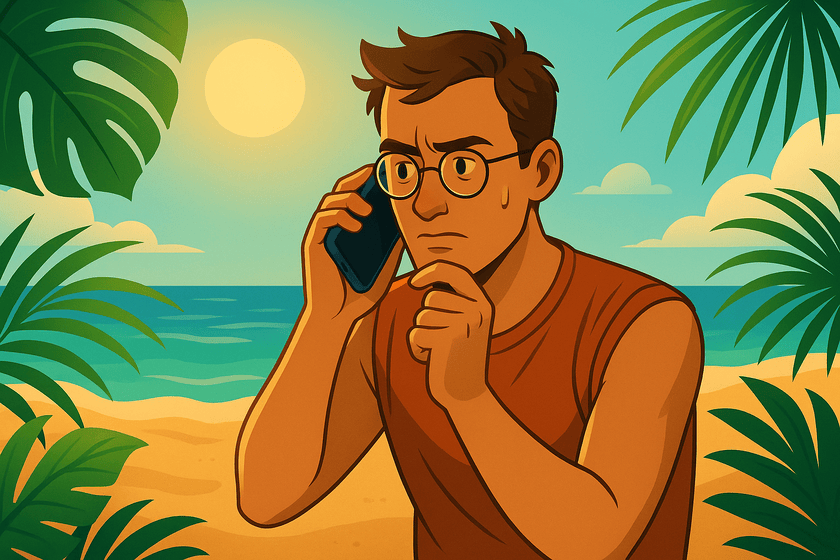

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         


In [1279]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

## Ogólna analiza dataframe

In [1280]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [1281]:
titanic_df.describe(include="all")

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


In [1282]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Przygotowanie danych
Widzimy strasznie dużo braków danych o numerze kabiny, dlatego zmienimy na informację, czy pasażer miał kabinę (HasCabine), bo zostawiając w początkowym stanie, nie wyciągniemy z tego zbyt dużo informacji.

In [1283]:
titanic_df["HasCabin"] = titanic_df["Cabin"].notna().astype(int)

titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0


In [1284]:
titanic_df.drop(columns="Cabin", inplace=True)

Wypełniamy braki danych o porcie (Embarked): oznaczymy nieznany port jako U = Unknown

In [1285]:
titanic_df.loc[titanic_df["Embarked"].isnull(), "Embarked"] = "U"

Teraz wypełniamy braki w danych numerycznych (Age, Fare)

1. Sprawdzimy czy rozkład jest zbliżony do normalnego
2. Wypełnimy braki

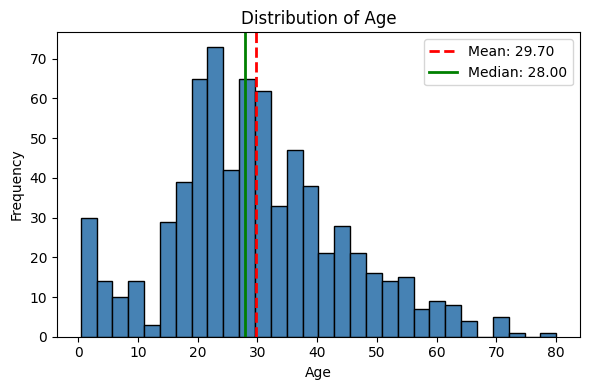

<Axes: >

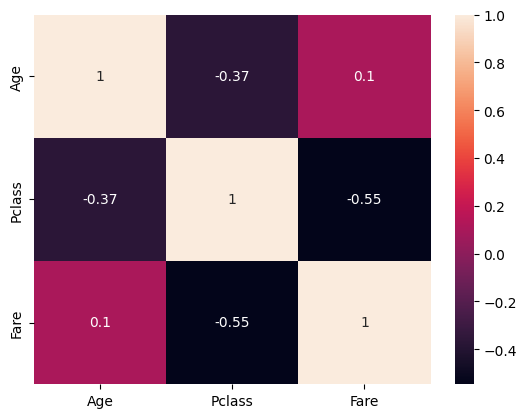

In [1286]:
def plot_numeric_histogram(df, column_name):
    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_numeric_histogram(titanic_df, "Age")
sns.heatmap(titanic_df[["Age", "Pclass", "Fare"]].corr(), annot=True)

> Z wykresów widzimy, że rozkład Age jest zbliżony do normalnego, a także Age w pewien sposób ma powiązanie z Pclass, dlatego wypełnimy dane medianą wieku w klasie, do której należał pasażer.

In [1287]:
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df.groupby(['Pclass'])['Age'].transform('median'))
titanic_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0


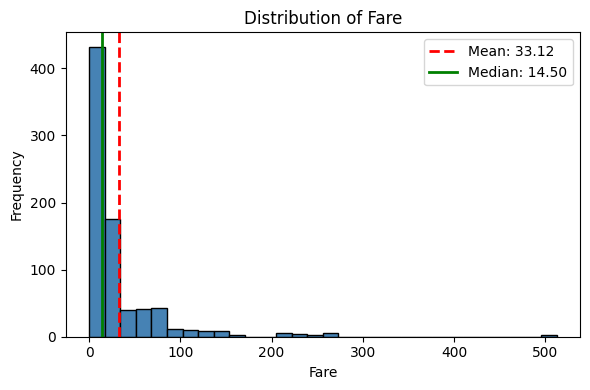

In [1288]:
plot_numeric_histogram(titanic_df, "Fare")

In [1289]:
len(titanic_df["Fare"].unique())

237

> Natomiast rozkład ceny biletów (Fare) jest prawoskośny i ceny są jednakowe dla kilku pasażerów(236 różnych cen + null na 891 pasażera), dlatego wypełnimy wartościami losowymi z tego rozkładu, uwzgłędniając istniejące prawdopodobieństwa.

In [1290]:
fare_counts = titanic_df['Fare'].value_counts(normalize=True)

fare_values = fare_counts.index.values
fare_probs = fare_counts.values

missing_fare = titanic_df['Fare'].isna()

titanic_df.loc[missing_fare, 'Fare'] = np.random.choice(fare_values, size=missing_fare.sum(), p=fare_probs)

len(titanic_df["Fare"].unique()) #powinno być na 1 mniej niż było wcześniej (236)

236

In [1291]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
 10  HasCabin  891 non-null    int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 83.5+ KB


> Widzimy, że już nie mamy braków danych

## Badanie występowania wartości skrajnych
### Wartości numeryczne
>Sprawdźmy rozkład i outliery

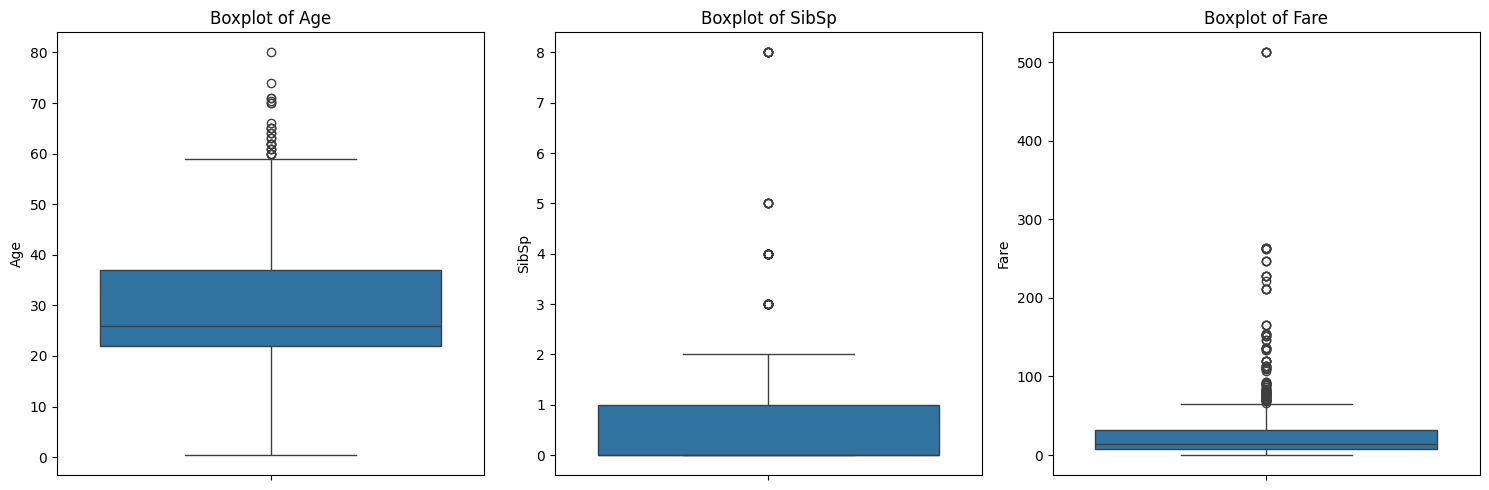

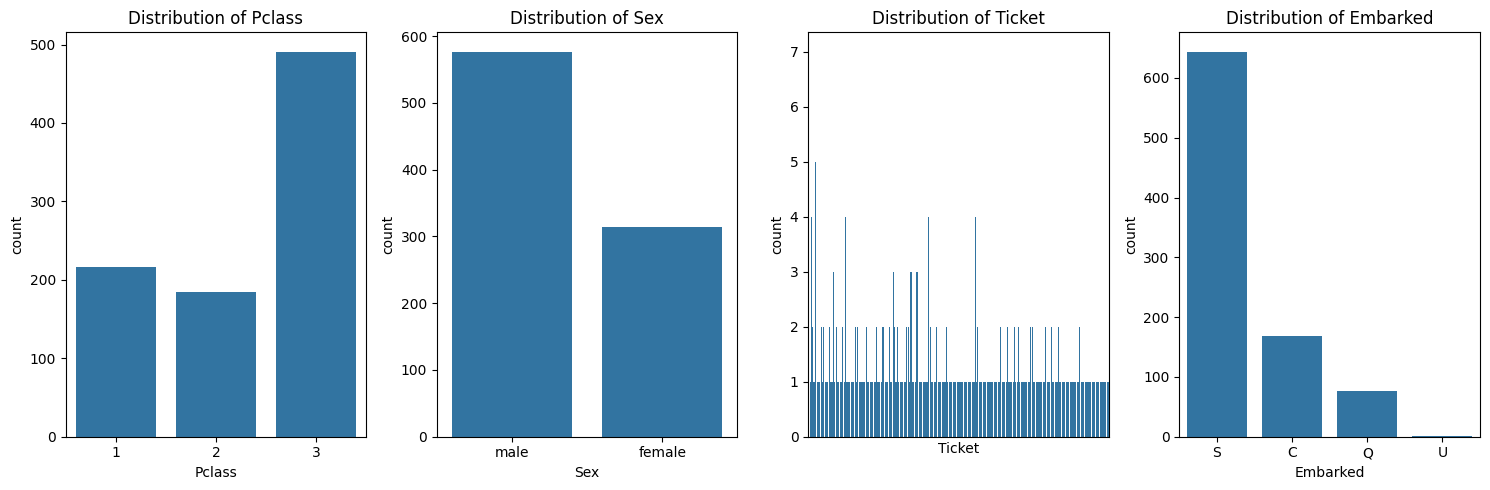

In [1292]:
def plot_outliers_and_distribution(df, numeric_cols, categorical_cols):
    # numeric
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(1, len(numeric_cols), i)
        sns.boxplot(y=df[col])
        plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

    # categorical
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(1, len(categorical_cols), i)
        sns.countplot(data=df, x=col)
        plt.title(f"Distribution of {col}")
        if col == "Ticket":
          plt.xticks([])
    plt.tight_layout()
    plt.show()


numeric_cols = ["Age",  "SibSp", "Fare"]
categorical_cols = ["Pclass", "Sex", "Ticket", "Embarked"]
plot_outliers_and_distribution(titanic_df, numeric_cols, categorical_cols)

**Numeryczne**
- Widzimy, że z wartości numerycznych tylko Age ma rozkład zbliżony do normalnego. Możemy też zauważyć, że wiek pasażerów był średnio od 22 do 38 lat, ale też są legendarni pasażerowie w wyjątkowo dużym wieku okolo 80 lat

- Pasażerowie mieli na pokładzie 0 lub 1 rodzeństwa/małżonków, chociaż widzimy też kilka wyjątkowych sytuacji, gdzie było nawet 5 lub 8 osób.

- Ogromna większość biletów była tania, a punkty rozciągające się aż do ponad 500 to najdroższe bilety pierwszej klasy

**Kategoryjne**
- Rozkład klas pasażerów potwierdza to, że bilety 3 klasy byłi najtańsi i było ich najwięcej

- Rozkład płci pasażerów pokazuje, że liczba mężczyzn była o okolo 2 razy większa. Jednak ta podróż odbyła się na początku 20 wieku..

> Ekologiczne podejście do drukowania biletów 🐮
- Na rozkładzie biletów możemy zauważyć, że do jednego biletu była wpisana cała rodzina lub osoby jej towarzyszące (od 0 dopisanych osób aż do 4).

- Z rozkładu Embarked wiemy też, że większość pasażerów dosiadła w porcie Southampton (może to był port pociątku podróży?). Jest też kilka osób z nieznanym portem początkowym (może ktoś zapomniał wpisać dane? a może te osoby mieli możliwość zacząć swoją podróż z każdego portu?)

### Dodanie dodatkowych kolumn
> Mając kolumnę z informacją o wieku pasażerów, możemy otrzymać informację czy pasażer był dzieckiem, bo kto wie, czy miało to wpływ na szansę przeżycia?

In [1293]:
titanic_df["IsChild"] = titanic_df["Age"].apply(lambda x: 1 if x < 18 else 0)
titanic_df.sample(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,IsChild
PassengerId,,,,,,,,,,,,
301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,24.0,0,0,9234,7.7500,Q,0,0
158,0,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.0500,S,0,0
746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,S,1,0
279,0,3,"Rice, Master. Eric",male,7.0,4,1,382652,29.1250,Q,0,1
120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.2750,S,0,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S,0,0
830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0000,U,1,0
628,1,1,"Longley, Miss. Gretchen Fiske",female,21.0,0,0,13502,77.9583,S,1,0
879,0,3,"Laleff, Mr. Kristo",male,24.0,0,0,349217,7.8958,S,0,0


> Z danych możemy też dowiedzieć się jaki jest całkowity rozmiar rodziny pasażera na Titanicu

In [1294]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

> Też ważną może być informacja, czy był pasażer sam, czy jednak był z nim ktoś z rodziny

In [1295]:
titanic_df['IsAlone'] = titanic_df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

## Przygotowujemy dane kategoryjne

In [1296]:
len(titanic_df["Ticket"].unique())

681

> Możemy zauważyć, że biletów było mniej, niż pasażerów. Wiedząc, że każdy pasażer miał bilet, rozumiemy, iż w 1 bilecie mogło być wpisane kilka osób

In [1297]:
titanic_df.groupby("Ticket").size().sample(10)

,0
Ticket,
SOTON/OQ 3101317,1
345770,1
113051,1
335097,1
S.W./PP 752,1
365226,1
2669,1
347074,1
239854,1


> To pokazuje, że myśleliśmy dobrze i każdy bilet mógł być wydany dla kilku pasażerów. Czyli teraz wyciągniemy z tego informację o liczbie osób na tym bilecie, natomiast sam numer biletu usuniemy

In [1298]:
titanic_df["TicketSize"] = titanic_df.groupby("Ticket")["Ticket"].transform("size")

titanic_df[["Ticket", "TicketSize"]]

,Ticket,TicketSize
PassengerId,,
1,A/5 21171,1
2,PC 17599,1
3,STON/O2. 3101282,1
4,113803,2
5,373450,1
...,...,...
887,211536,1
888,112053,1
889,W./C. 6607,2


In [1299]:
titanic_df.drop(columns=['Ticket'], inplace=True)

In [1300]:
len(titanic_df["Name"].unique())

891

> Usuniemy kolumnę Name, gdyż dla każdego pasażera jest to wartość unikatowa i nie możemy z tej kolumny otrzymać dodatkowych danych.

In [1301]:
titanic_df.drop(columns=['Name'], inplace=True)

> Mapujemy pozostałe dane kategoryjne na wartości numeryczne

In [1302]:
titanic_df["Embarked"].unique()

array(['S', 'C', 'Q', 'U'], dtype=object)

In [1303]:
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], prefix='Embarked', dtype=int)

In [1304]:
titanic_df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [1305]:
titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})

In [1306]:
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,IsChild,FamilySize,IsAlone,TicketSize,Embarked_C,Embarked_Q,Embarked_S,Embarked_U
PassengerId,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,0,2,0,1,0,0,1,0
2,1,1,1,38.0,1,0,71.2833,1,0,2,0,1,1,0,0,0
3,1,3,1,26.0,0,0,7.9250,0,0,1,1,1,0,0,1,0
4,1,1,1,35.0,1,0,53.1000,1,0,2,0,2,0,0,1,0
5,0,3,0,35.0,0,0,8.0500,0,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,0,27.0,0,0,13.0000,0,0,1,1,1,0,0,1,0
888,1,1,1,19.0,0,0,30.0000,1,0,1,1,1,0,0,1,0
889,0,3,1,24.0,1,2,23.4500,0,0,4,0,2,0,0,1,0


## Oddzielenie cech(X) od docelowej wartości(y)

In [1307]:
X = titanic_df.drop(columns="Survived")
y = titanic_df["Survived"]

X #cechy pasażera

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,IsChild,FamilySize,IsAlone,TicketSize,Embarked_C,Embarked_Q,Embarked_S,Embarked_U
PassengerId,,,,,,,,,,,,,,,
1,3,0,22.0,1,0,7.2500,0,0,2,0,1,0,0,1,0
2,1,1,38.0,1,0,71.2833,1,0,2,0,1,1,0,0,0
3,3,1,26.0,0,0,7.9250,0,0,1,1,1,0,0,1,0
4,1,1,35.0,1,0,53.1000,1,0,2,0,2,0,0,1,0
5,3,0,35.0,0,0,8.0500,0,0,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,2,0,27.0,0,0,13.0000,0,0,1,1,1,0,0,1,0
888,1,1,19.0,0,0,30.0000,1,0,1,1,1,0,0,1,0
889,3,1,24.0,1,2,23.4500,0,0,4,0,2,0,0,1,0


In [1308]:
y #czy pasażer przeżył

,Survived
PassengerId,
1,0
2,1
3,1
4,1
5,0
...,...
887,0
888,1
889,0


## Analiza graficzna

### Macierz korelacji
> Sprawdźmy, czy macierz korelacji pokaże jeszcze coś

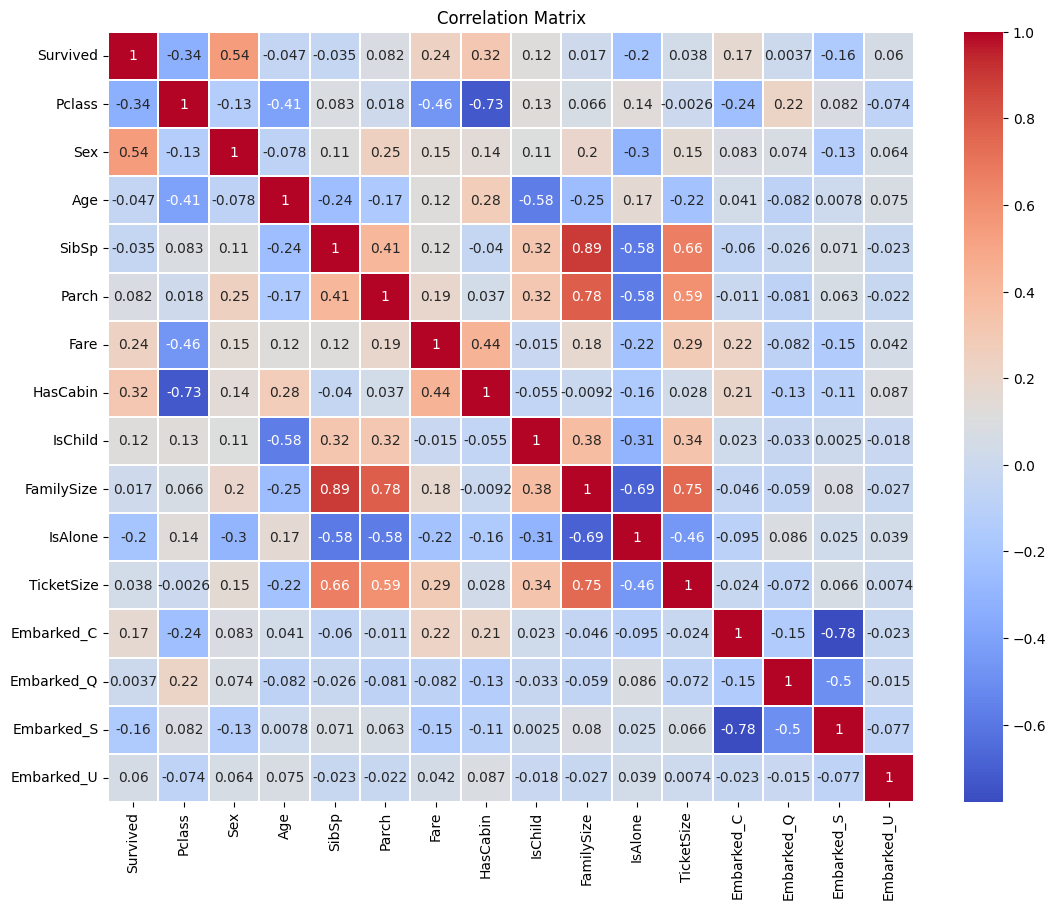

In [1309]:
plt.figure(figsize=(13, 10))
sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.2)
plt.title('Correlation Matrix')
plt.show()

### Sprawdżmy też jaka była ogólna szansa na przeżycie

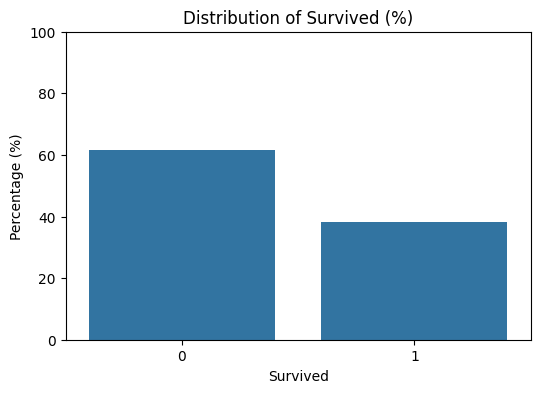

In [1310]:
data_perc = titanic_df['Survived'].value_counts(normalize=True).reset_index()
data_perc.columns = ['Survived', 'Percentage']
data_perc['Percentage'] *= 100

plt.figure(figsize=(6, 4))
sns.barplot(data=data_perc, x='Survived', y='Percentage')
plt.title("Distribution of Survived (%)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.show()

## Wnioski

> Otrzymane informację o pasażerach zostały wyczyścione od zbędnych danych poprzez odrzucenie i przekształcenie szumu tekstowego i wyczyścienie braków danych, np. surowe kolumny takie jak Ticket, Cabin zostały odpowiednio przekształcone i zmienione, co pomogło w przeanalizowaniu zależności cech pasażera i jego szans na przeżycie

> **Bezwzględne zachowanie outlierów:** Wartości odstające wykryte w kolumnach numerycznych (np. ekstremalnie wysokie ceny biletów Fare czy wiek seniorów) odzwierciedlają rzeczywiste różnice klasowe na statku. Zamiast usuwania ich jako błędów, stanowią one cenne informacje dla modelu.

Po analizie i opracowaniu danych możemy odczytać z macierzy korelacji, że **na przeżycie największy wpływ mieli**:

- *Płeć osoby (Sex):* Najsilniejszy dodatni czynnik korelacji, co potwierdza zasadę `kobiety i dzieci pierwsi` w odniesieniu do dorosłych pasażerek

- *Status społeczno-ekonomiczny (Pclass, HasCabin, Fare):* Majątek i klasa biletowa też decydowały o życiu. Pasażerowie z 1. klasy, opłacający najwyższe taryfy i posiadający przypisane kabiny, przeżywali znacznie częściej niż podróżni z 3. klasy

- *Wielkość rodziny i grupy (IsAlone):* Pasażerowie podróżujący w pojedynkę statystycznie rzadziej przeżywali katastrofę niż osoby podróżujące z rodziną czy w grupie


